# Prévision du volume de visites aux urgences par lissage exponentiel (PROC ESM)


## Synthèse

Un système hospitalier de taille moyenne a besoin d'une prévision à un an du volume mensuel de visites au service des urgences (SU) pour planifier la dotation en personnel infirmier et la capacité en lits avant la vague respiratoire hivernale. Ce notebook construit un recensement mensuel synthétique des urgences sur quatre ans (48 mois, janv. 2021 - déc. 2024) et ajuste un modèle saisonnier multiplicatif de Winters avec **PROC ESM** pour produire une prévision à 12 mois assortie d'intervalles de prédiction à 95 %.

Le modèle ajusté capture bien la série : en échantillon, le **RMSE est d'environ 320 visites** et le **MAPE de 4,16 %**, si bien que l'erreur mensuelle typique est inférieure à 5 % du volume. La prévision projette la forme saisonnière familière dans 2025 - un pic décembre-février proche de **7 300-7 800 visites/mois** et un creux de fin d'été proche de **5 800-5 900** - avec des bandes de prédiction qui s'élargissent à mesure que l'horizon s'étend. Ces chiffres, et les poids de lissage qui les sous-tendent, sont lus directement dans les jeux de données de sortie de la procédure ci-dessous.


## Sources de données

| Jeu de données | Lignes | Granularité | Variables clés | Description |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Une ligne par mois calendaire, janv. 2021 - déc. 2024 | `month` (date SAS mensuelle), `ed_visits` (nombre entier de visites mensuelles aux urgences) | Volume synthétique mensuel de visites au service des urgences pour un système hospitalier de taille moyenne. Généré avec une tendance de croissance à la hausse (~3 % par an), un cycle saisonnier multiplicatif culminant durant la saison respiratoire hivernale (déc.-févr.) et fléchissant en fin d'été, plus un bruit log-normal afin que l'amplitude saisonnière croisse avec le niveau en hausse. |


# Prévision du volume de visites aux urgences avec PROC ESM

Les planificateurs de capacité ont besoin de savoir combien de visites aux urgences attendre chaque mois afin de programmer le personnel infirmier, réserver des lits flexibles et préparer les fournitures respiratoires avant la vague hivernale. Le volume des urgences est une série temporelle saisonnière d'école : il croît lentement d'année en année, culmine durant la saison respiratoire de décembre à février, et reflue en fin d'été, et l'ampleur de l'oscillation saisonnière augmente à mesure que le volume de base augmente. Cette structure saisonnière multiplicative est exactement ce que la méthode multiplicative de Winters dans **PROC ESM** est conçue pour capturer.

Dans ce notebook, nous :

1. Générons un recensement mensuel réaliste des urgences sur quatre ans avec tendance, saisonnalité multiplicative et bruit.
2. Visualisons la série pour confirmer sa structure saisonnière multiplicative.
3. Ajustons un modèle multiplicatif de Winters avec PROC ESM et lisons ses poids de lissage et ses statistiques d'ajustement dans les jeux de données de sortie.
4. Produisons une prévision à 12 mois avec des intervalles de prédiction à 95 % et interprétons les implications opérationnelles.


## Étape 1 - Générer le recensement mensuel synthétique des urgences

Nous construisons 48 observations mensuelles de janvier 2021 à décembre 2024. Le volume attendu de chaque mois est un niveau de base qui croît d'environ 3 % par an, multiplié par un indice saisonnier (le plus élevé au milieu de l'hiver, le plus bas en fin d'été), puis perturbé par un bruit log-normal afin que la variation aléatoire croisse avec le niveau. `intnx` avance la date alignée sur le mois d'une période par ligne, et `streaminit` rend le tirage reproductible.


In [1]:
DONNÉES ed_census;
    APPELER streaminit(20240531);
    /* Indice saisonnier mensuel : pics déc.-févr. (grippe/VRS), creux août-sept. */
    TABLEAU seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    FAIRE i = 1 JUSQU_À 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Base ~6000 visites/mois croissant ~3 % par an */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Saisonnalité multiplicative + bruit lognormal proportionnel au niveau */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        SORTIE;
    FIN;
    GARDER month ed_visits;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=ed_census(obs=14) noobs ÉTIQUETTE;
    ÉTIQUETTE month = "Mois" ed_visits = "Visites aux urgences";
    TITRE "Les 14 premiers mois du volume synthétique de visites aux urgences";
EXÉCUTER;

                           Les 14 premiers mois du volume synthétique de visites aux urgences                           

  Mois  Visites aux urgences
202101                  7103
202102                  6835
202103                  6668
202104                  5611
202105                  5816
202106                  5383
202107                  5586
202108                  5283
202109                  5161
202110                  6109
202111                  6451
202112                  6730
202201                  6847
202202                  7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Les premiers mois confirment la conception : le volume s'ouvre près de 7 100 au pic de janvier 2021, chute au printemps et en été jusqu'à son creux d'août-septembre, puis remonte vers l'hiver suivant. En janvier 2022, le pic a légèrement grimpé à environ 6 800-7 200, reflétant la croissance annuelle de ~3 % superposée au cycle saisonnier.


## Étape 2 - Visualiser la série

Avant de modéliser, traçons la série brute pour confirmer la structure attendue : une légère tendance à la hausse avec un pic annuel récurrent chaque hiver dont l'amplitude s'élargit au fil du temps. Une oscillation saisonnière qui s'élargit est la signature d'un processus saisonnier *multiplicatif* et nous indique quel modèle ESM choisir.


                           Les 14 premiers mois du volume synthétique de visites aux urgences                           




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


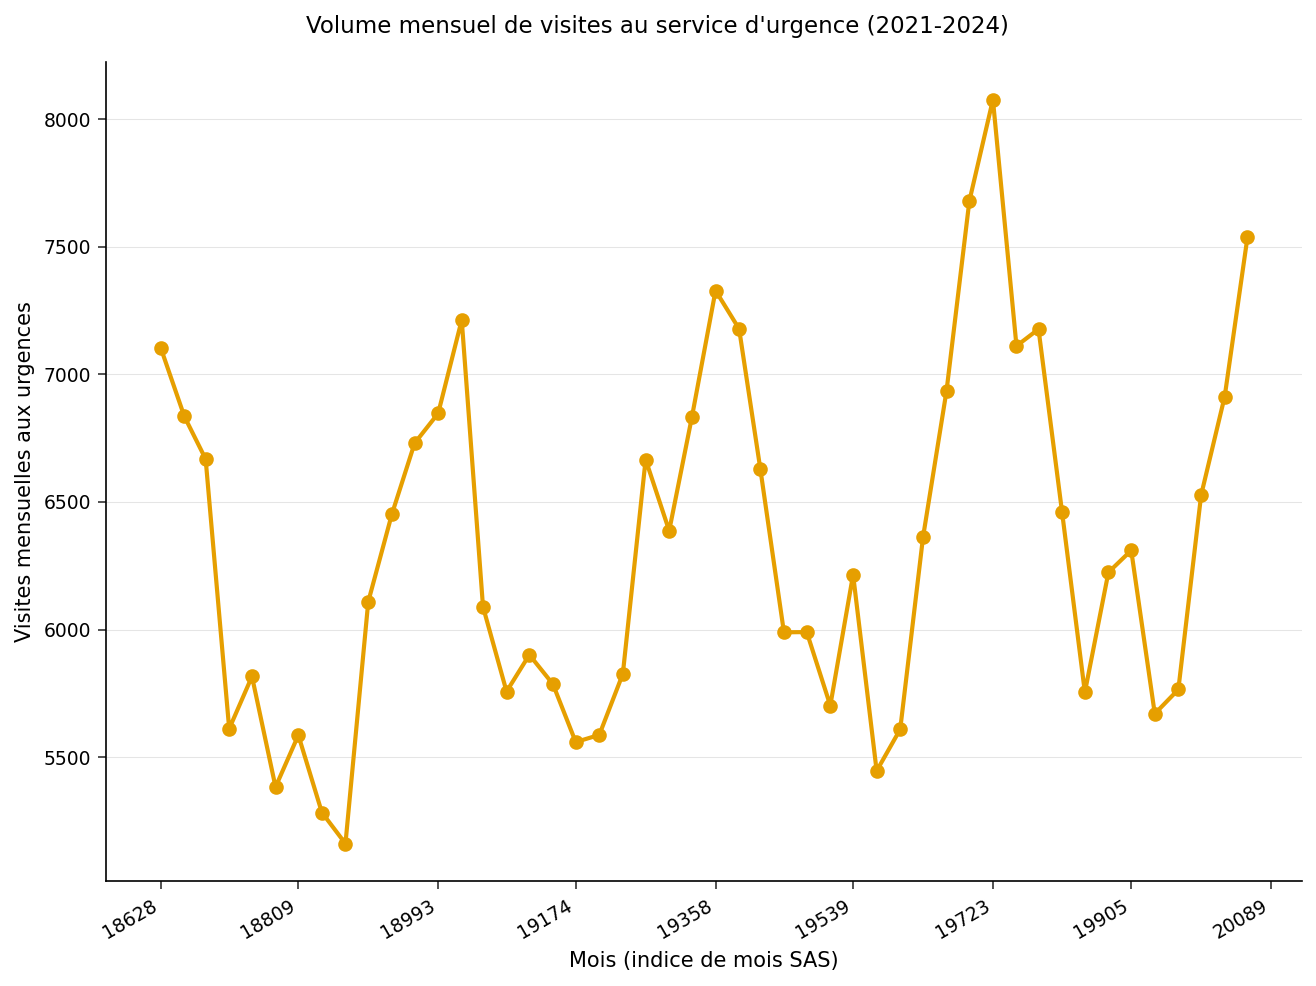

In [2]:
PROCÉDURE SGPLOT DONNÉES=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ÉTIQUETTE="Mois (indice de mois SAS)";
    YAXIS ÉTIQUETTE="Visites mensuelles aux urgences" grid;
    TITRE "Volume mensuel de visites au service d'urgence (2021-2024)";
EXÉCUTER;

Le graphique montre quatre cycles annuels nets. Chaque pic hivernal se situe un peu plus haut que le précédent, grimpant d'environ 7 100 en 2021 à environ 8 100 au pic de 2024, tandis que les creux estivaux montent plus modestement - l'oscillation saisonnière croît avec le niveau. Cette amplitude qui s'élargit est la marque de la saisonnalité multiplicative et justifie `MODEL=WINTERS` (Winters multiplicatif) à l'étape suivante.


## Étape 3 - Ajuster le modèle multiplicatif de Winters

Nous ajustons un lissage saisonnier multiplicatif de Winters sur l'historique complet de 48 mois. L'instruction `ID` déclare `month` comme index temporel à un intervalle `MONTH`, et l'instruction `FORECAST` demande `MODEL=WINTERS` avec `LEAD=12` pour projeter un an à l'avance. Nous capturons trois jeux de données de sortie :

- `OUT=` - la série historique avec la prévision ajoutée (une colonne `ed_visits`), l'ID temporel étant étendu sur l'horizon de prévision - idéal pour le tracé.
- `OUTFOR=` - les composantes de prévision par période : prévision ponctuelle (`PREDICT`) et les limites de prédiction inférieure/supérieure.
- `OUTSUM=` - les statistiques d'ajustement du modèle (RMSE, MAE, MAPE, AIC) et les poids de lissage, en une seule ligne de synthèse.

`ALPHA=0.05` produit des limites de prédiction à 95 %, appropriées pour les marges de risque de planification de capacité. `PRINT=(STATISTICS)` reproduit les statistiques d'ajustement et les poids de lissage dans la sortie.


In [3]:
PROCÉDURE esm DONNÉES=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        IMPRIMER=(statistics);
    id month interval=month;
    forecast ed_visits / MODÈLE=winters ALPHA=0.05;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=esm_summary noobs ÉTIQUETTE;
    ÉTIQUETTE rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="Niveau (alpha)" beta="Tendance (bêta)" gamma="Saison (gamma)";
    VAR rmse mae mape ALPHA beta gamma;
    TITRE "Statistiques d'ajustement de Winters et poids de lissage";
EXÉCUTER;

                           Les 14 premiers mois du volume synthétique de visites aux urgences                           


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                Statistiques d'ajustement de Winters et poids de lissage                                

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


La ligne `OUTSUM=` et les statistiques imprimées concordent : l'ajustement multiplicatif de Winters atteint en échantillon un **RMSE de 320,4 visites**, un **MAE de 264,4** et un **MAPE de 4,16 %** - une erreur mensuelle typique bien inférieure à 5 % du volume, ce qui est confortablement précis pour la planification du personnel. Les poids de lissage sont **alpha = 0,30** (niveau), **bêta = 0,10** (tendance) et **gamma = 0,10** (saison). Le poids modéré du niveau laisse la base dériver vers le haut avec la croissance de la population de patients, tandis que les faibles poids de tendance et de saison reflètent le fait que le taux de croissance et la forme de la vague hivernale sont stables d'une année à l'autre et ne devraient pas faire l'objet de sur-réactions d'un mois à l'autre.

> Note : ce sont des statistiques d'ajustement *en échantillon* calculées sur l'échantillon d'estimation, et non sur un échantillon de validation hors-échantillon. Elles quantifient à quel point le modèle suit fidèlement l'historique sur lequel il a été ajusté.


## Étape 4 - Assembler et tabuler la prévision à 12 mois

Le jeu de données `OUTFOR=` contient la prévision ponctuelle et les limites de prédiction pour chaque période, tandis que le jeu de données `OUT=` porte l'ID temporel étendu proprement sur l'horizon de prévision. Nous alignons les deux par ordre d'observation pour attacher les dates de prévision aux limites de prédiction, puis ne conservons que les 12 mois prévus. Ce sont les chiffres sur lesquels un comité de dotation agirait.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
DONNÉES out_idx;
    DÉFINIR ed_with_forecast;
    row = _n_;
    RENOMMER month = fdate ed_visits = series_value;
EXÉCUTER;

DONNÉES for_idx;
    DÉFINIR esm_forecast;
    row = _n_;
    RENOMMER ed_visits = observed;
    GARDER row observed predict LOWER UPPER;
EXÉCUTER;

DONNÉES forecast_path;
    FUSIONNER out_idx for_idx;
    PAR row;
    format fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
EXÉCUTER;

DONNÉES forecast_horizon;
    DÉFINIR forecast_path;
    OÙ observed = .;   /* forecast months only (no observed value) */
    GARDER fdate predict LOWER UPPER;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=forecast_horizon noobs ÉTIQUETTE;
    ÉTIQUETTE fdate   = "Mois"
          predict = "Visites prévues"
          LOWER   = "Borne inf. 95 %"
          UPPER   = "Borne sup. 95 %";
    TITRE "Prévision des visites aux urgences sur 12 mois avec limites de prévision à 95 %";
EXÉCUTER;


                    Prévision des visites aux urgences sur 12 mois avec limites de prévision à 95 %                     

  Mois   Visites prévues  Borne inf. 95 %  Borne sup. 95 %
202501             7,822            7,194            8,450
202502             7,539            6,651            8,427
202503             7,292            6,204            8,380
202504             6,263            5,007            7,519
202505             6,397            4,992            7,801
202506             6,039            4,501            7,578
202507             6,236            4,574            7,897
202508             5,867            4,091            7,644
202509             5,802            3,918            7,686
202510             6,804            4,818            8,790
202511             7,173            5,090            9,256
202512             7,567            5,391            9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


La prévision reporte la signature saisonnière dans 2025. Le modèle projette le pic de janvier 2025 à environ **7 822 visites** (intervalle à 95 % 7 194-8 450), s'apaise au printemps, atteint son creux de fin d'été près de **5 802** en septembre (intervalle 3 918-7 686), puis remonte vers un pic de décembre d'environ **7 567** (intervalle 5 391-9 742). La bande de prédiction s'élargit régulièrement avec l'horizon - l'intervalle du mois prochain s'étend sur environ +/-630 visites, tandis que celui de décembre prochain dépasse +/-2 000 - un rappel direct que les plans à court terme sont bien plus fermes que ceux de fin d'année.


## Étape 5 - Tracer l'historique plus la prévision

Enfin, superposons la prévision sur l'historique observé afin que les planificateurs puissent voir le pic hivernal projeté et la bande d'incertitude qui s'élargit à mesure que l'horizon s'étend. Nous scindons la série alignée `forecast_path` en l'historique **observé** (trait plein) et la **prévision à 12 mois** (pointillés) afin que la transition soit claire, et traçons la bande de prédiction à 95 % en dessous. L'axe des x est l'index de date SAS mensuelle, courant de gauche à droite de janv. 2021 à déc. 2025.


                    Prévision des visites aux urgences sur 12 mois avec limites de prévision à 95 %                     




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


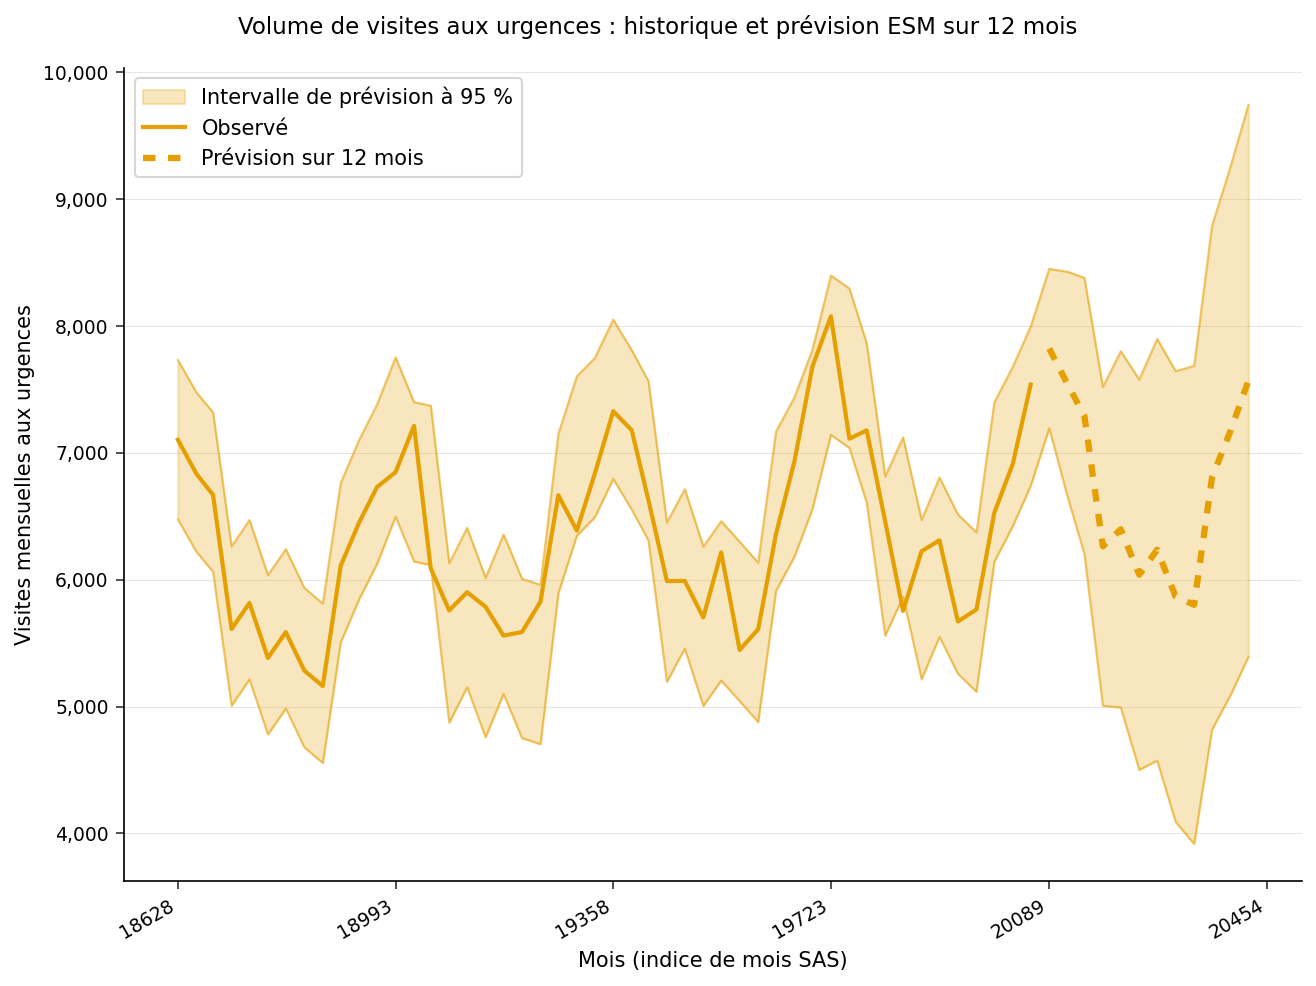

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
DONNÉES forecast_plot;
    DÉFINIR forecast_path;
    SI observed = . ALORS fc_only = predict;   /* future months only */
    SINON fc_only = .;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="Intervalle de prévision à 95 %" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="Observé";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="Prévision sur 12 mois";
    XAXIS ÉTIQUETTE="Mois (indice de mois SAS)";
    YAXIS ÉTIQUETTE="Visites mensuelles aux urgences" grid;
    TITRE "Volume de visites aux urgences : historique et prévision ESM sur 12 mois";
EXÉCUTER;


## Interprétation des résultats

Le modèle multiplicatif de Winters décompose le volume des urgences en un **niveau** en hausse lente, une **tendance** quasi plate et un motif **saisonnier** stable. Les poids de lissage lus dans `OUTSUM=` racontent l'histoire : un poids modéré du niveau (alpha = 0,30) laisse la base dériver vers le haut avec la croissance de la population de patients, tandis que de faibles poids de tendance et de saison (bêta = gamma = 0,10) reflètent le fait que le taux de croissance et la forme de la vague hivernale sont très stables d'une année à l'autre et ne devraient pas faire l'objet de sur-réactions d'un mois à l'autre.

Les **statistiques d'ajustement** confirment que le modèle suit bien l'historique : un RMSE d'environ 320 visites et un MAPE de 4,16 % signifient que l'erreur mensuelle typique est inférieure à 5 % du volume. Sur le plan opérationnel, la **table de prévision et le graphique à bande** quantifient le pic décembre-février vers lequel les urgences devraient doter le personnel - environ 7 300-7 800 visites durant les mois d'hiver - et les limites de prédiction à 95 % définissent une fourchette de capacité prudente : planifier la dotation de base sur la prévision ponctuelle, et pré-organiser une couverture flexible et des lits de débordement vers la limite supérieure. L'intervalle s'élargit avec l'horizon, si bien que le plan du mois prochain est bien plus ferme que celui de décembre prochain et devrait être rafraîchi à mesure que de nouvelles données réelles arrivent.

**Extensions :** comparer `MODEL=ADDWINTERS` (saisonnalité additive) à l'ajustement multiplicatif pour confirmer le choix multiplicatif ; appliquer `TRANSFORM=LOG` pour imposer la positivité et stabiliser la variance ; ou ajouter une instruction `BY` pour prévoir plusieurs sites hospitaliers en un seul appel PROC ESM.
